# Smart LogiTrack - Système Prédictif de Transport Urbain (ETA)

### The Process

* `Ingest` Read the file (Parquet/CSV).

* `Clean` Handle Nulls, filter outliers.

* `Feature Eng` Create new variables.

* `Split` Separate Train / Test.

* `Train` model.fit()

* `Evaluate` Compare the prediction to reality.

## pyspark's test

In [1]:
""" from pyspark.sql import SparkSession
import sys

# 1. Initialize Spark (Spark 4.x style)
spark = SparkSession.builder \
    .appName("DistutilsCheck") \
    .getOrCreate()

# 2. Print versions to verify context
print(f"python version: {sys.version}")
print(f"spark version: {spark.version}")

# 3. Create a simple DataFrame (triggers the internal worker setup)
data = [("LogiTrack", 1), ("Test", 2)]
df = spark.createDataFrame(data, ["Project", "ID"])

df.show()
print("✅ If you see the table above, distutils is NOT an issue!") """

' from pyspark.sql import SparkSession\nimport sys\n\n# 1. Initialize Spark (Spark 4.x style)\nspark = SparkSession.builder     .appName("DistutilsCheck")     .getOrCreate()\n\n# 2. Print versions to verify context\nprint(f"python version: {sys.version}")\nprint(f"spark version: {spark.version}")\n\n# 3. Create a simple DataFrame (triggers the internal worker setup)\ndata = [("LogiTrack", 1), ("Test", 2)]\ndf = spark.createDataFrame(data, ["Project", "ID"])\n\ndf.show()\nprint("✅ If you see the table above, distutils is NOT an issue!") '

## Bronze layer
### Data Loading 

In [2]:
from pyspark.sql import SparkSession

# --- session config 
my_spark=SparkSession.builder.appName("Smart-Logistic").getOrCreate()
print(my_spark)

# --- loading data
df_path="../data/bronze_taxi.parquet"
df_bronze=my_spark.read.parquet(df_path)
df_bronze.show(5)
print("_________________________")
shape=(df_bronze.count(), len(df_bronze.columns))
print(f"shape (lines, cols) : {shape}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/15 11:05:25 WARN Utils: Your hostname, MAE, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/15 11:05:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/15 11:05:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-01-01 00:18:38|  2025-01-01 00:26:59|              1|          1.6|         1|                 N|         229|    

In [3]:
print("=== schema ===")
df_bronze.printSchema()

=== schema ===
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [4]:
# --- pyspark : select obj col
print(" === obj col ===")
str_col=[c for c,t in df_bronze.dtypes if t.startswith('string')]
df_obj=df_bronze.select(str_col).show(3)
print(f"string col : {str_col}")

# --- possible val : obj col
print(f" === possible val of {df_obj} === ")
df_bronze.select('store_and_fwd_flag').distinct().show()
# df_obj=df_bronze.select_dtypes(['object'])
# df_obj.head(100)
# df_bronze['store_and_fwd_flag'].unique()

 === obj col ===


+------------------+
|store_and_fwd_flag|
+------------------+
|                 N|
|                 N|
|                 N|
+------------------+
only showing top 3 rows
string col : ['store_and_fwd_flag']
 === possible val of None === 


+------------------+
|store_and_fwd_flag|
+------------------+
|                 Y|
|                 N|
|              NULL|
+------------------+



## Silver layer
### Target creation

In [ ]:
from pyspark.sql.functions import col, unix_timestamp 

# tpep_pickup_datetime, tpep_dropoff_datetime: timestamp_ntz (nullable = true)
target_duration=df_bronze.withColumn(
    "duration_seconds", 
    unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime"))
)

target_min=target_duration.withColumn(
    "target_duration",
    col("duration_seconds") / 60
)
target_min.select("tpep_pickup_datetime", "tpep_dropoff_datetime", "target_duration")

DataFrame[tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, target_duration: double]

### Correlation

Text(0.5, 1.0, 'Correlation')

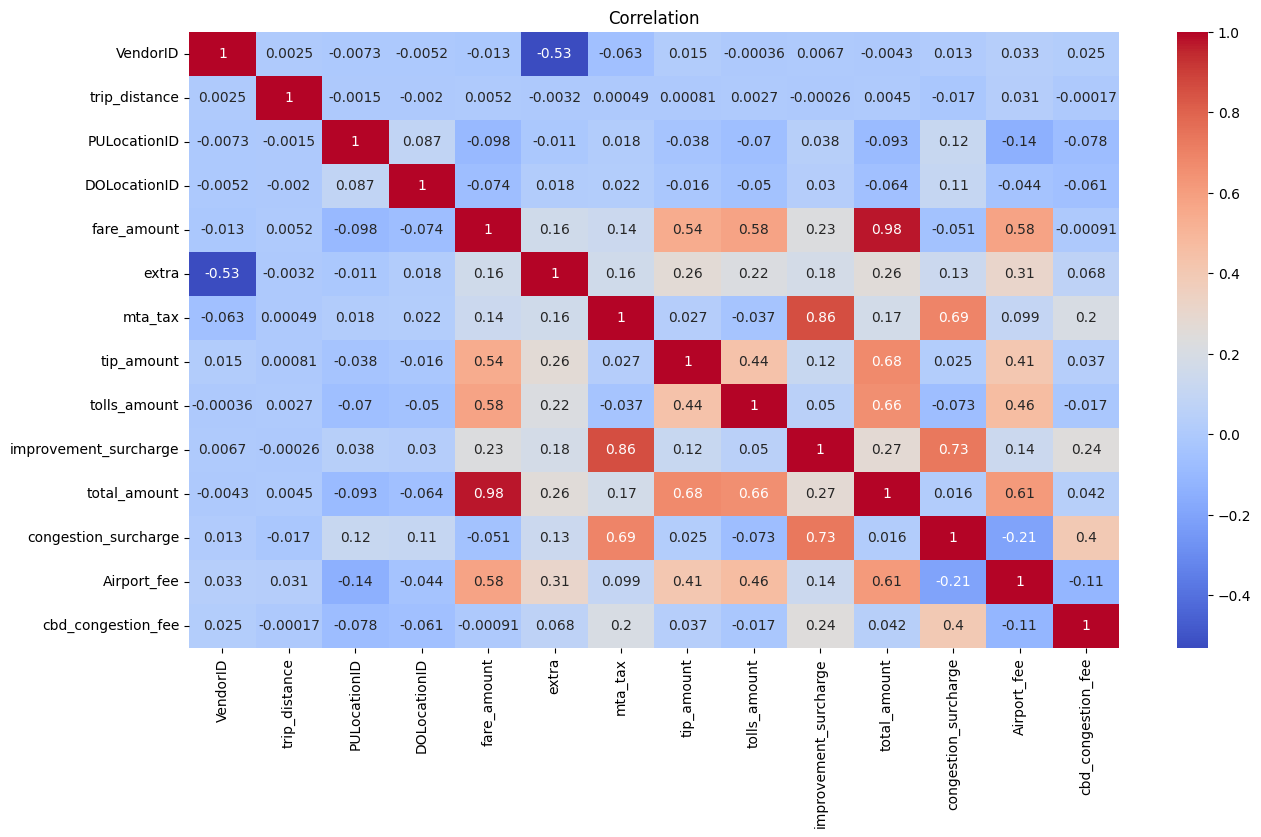

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- select : num col
num_types=["int", "float", "double", "long"]
num_col= [c for c,t in df_bronze.dtypes if t in num_types]
df_numeric = df_bronze.select(num_col)  # df : only num

# --- heatmap
pdf=df_numeric.sample(fraction=0.1, seed=42).toPandas()
corr_matrix=pdf.corr()      # correlation Calcul

# --- graph
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation")
# plt.show()


## Chargement des Données (Bronze)

## Nettoyage et Feature Engineering (Vers Silver)

In [ ]:
# 1. Conversion des dates et calcul de la durée (Target)
df_silver = df_bronze.withColumn(
    "duration_minutes",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

# 2. Application des filtres métier (Brief)
# - Distance entre 0 et 200 miles
# - Durée positive
# - Nombre de passagers > 0
df_silver = df_silver.filter(
    (col("trip_distance") > 0) & 
    (col("trip_distance") <= 200) &
    (col("duration_minutes") > 0) & 
    (col("duration_minutes") < 300) & # Filtre outlier durée extrême (>5h)
    (col("passenger_count") > 0)
)

# 3. Création des features temporelles
df_silver = df_silver.withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
                     .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) \
                     .withColumn("month", month("tpep_pickup_datetime"))

# Aperçu
df_silver.select("tpep_pickup_datetime", "duration_minutes", "trip_distance", "pickup_hour").show(5)

## EDA - Analyse Exploratoire (Visualisation)

In [ ]:
# On prend un échantillon de 10% pour l'analyse graphique afin de ne pas surcharger la mémoire
pdf_sample = df_silver.sample(fraction=0.1, seed=42).toPandas()

# 1. Distribution de la variable cible (Durée)
plt.figure(figsize=(10, 5))
sns.histplot(pdf_sample['duration_minutes'], bins=50, kde=True, color='blue')
plt.title("Distribution de la Durée des Trajets (Minutes)")
plt.xlim(0, 60) # Focus sur les trajets de moins d'une heure
plt.show()

# 2. Relation Distance vs Durée
plt.figure(figsize=(10, 5))
sns.scatterplot(x='trip_distance', y='duration_minutes', data=pdf_sample, alpha=0.3)
plt.title("Corrélation : Distance vs Durée")
plt.xlabel("Distance (Miles)")
plt.ylabel("Durée (Minutes)")
plt.xlim(0, 30)
plt.ylim(0, 100)
plt.show()

# 3. Durée moyenne par heure de la journée
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='duration_minutes', data=pdf_sample, estimator='mean', errorbar=None, marker='o')
plt.title("Durée moyenne des trajets par heure (Détection Heures de Pointe)")
plt.xticks(range(0, 24))
plt.show()

NameError: name 'df_silver' is not defined

## Analyse SQL Avancée (Prototypage pour API)

In [ ]:
# Création d'une vue temporaire pour utiliser Spark SQL
df_silver.createOrReplaceTempView("silver_taxi_trips")

# Requête 1 : Analyse des paiements (Brief: /analytics/payment-analysis)
query_payment = """
    SELECT 
        payment_type, 
        COUNT(*) as total_trips, 
        ROUND(AVG(duration_minutes), 2) as avg_duration 
    FROM silver_taxi_trips 
    GROUP BY payment_type 
    ORDER BY total_trips DESC
"""
spark.sql(query_payment).show()

# Requête 2 : Analyse horaire (Brief: /analytics/avg-duration-by-hour)
query_hourly = """
    SELECT 
        pickup_hour, 
        ROUND(AVG(duration_minutes), 2) as avg_duration 
    FROM silver_taxi_trips 
    GROUP BY pickup_hour 
    ORDER BY pickup_hour ASC
"""
spark.sql(query_hourly).show(5)

## Préparation au Machine Learning (Training)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Sélection des features
features = ['trip_distance', 'passenger_count', 'pickup_hour', 'day_of_week']
target = 'duration_minutes'

# Conversion Spark -> Pandas pour Scikit-Learn (Sur l'échantillon ou dataset complet si RAM suffisante)
# Ici on utilise l'échantillon précédent pour la rapidité du notebook
X = pdf_sample[features]
y = pdf_sample[target]

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

## Entraînement et Évaluation du Modèle

In [ ]:
# Initialisation du modèle
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# Entraînement
print("Début de l'entraînement...")
rf_model.fit(X_train, y_train)
print("Entraînement terminé.")

# Prédiction
y_pred = rf_model.predict(X_test)

# Métriques
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"R2 Score: {r2:.4f}")

# Feature Importance
import numpy as np
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nImportance des features :")
for f in range(X.shape[1]):
    print(f"{features[indices[f]]}: {importances[indices[f]]:.4f}")

## Sérialisation (Test de sauvegarde)

In [ ]:
# Test de sauvegarde pour vérifier que ça fonctionnera dans le script final
model_path = "models/model_notebook_test.pkl"
os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, model_path)
print(f"Modèle sauvegardé avec succès sous : {model_path}")

# Test de rechargement
loaded_model = joblib.load(model_path)
test_pred = loaded_model.predict(X_test.iloc[0:1])
print(f"Test prédiction (1 ligne) : {test_pred[0]:.2f} minutes")

## Arrêt de Spark

In [ ]:
spark.stop()

***

In [ ]:
import pandas as pd
import io

# Configuration
FILE_NAME = "data/bronze_taxi.parquet"
OUTPUT_FILE = "context_pour_ai_studio.txt"

def generate_report():
    try:
        df = pd.read_parquet(FILE_NAME)
        
        # Buffer pour écrire le rapport
        buffer = io.StringIO()
        
        buffer.write(f"--- RAPPORT CONTEXTUEL DE DONNÉES : {FILE_NAME} ---\n")
        buffer.write("Ce rapport décrit la structure et la distribution des données pour un projet Data Engineering.\n\n")
        
        # 1. MÉTADONNÉES GÉNÉRALES
        buffer.write(f"## 1. VOLUMÉTRIE\n")
        buffer.write(f"- Nombre de lignes : {len(df)}\n")
        buffer.write(f"- Nombre de colonnes : {len(df.columns)}\n")
        buffer.write(f"- Usage Mémoire (approx) : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n\n")
        
        # 2. ANALYSE DÉTAILLÉE PAR COLONNE
        buffer.write("## 2. DÉTAILS DES VARIABLES ET DISTRIBUTIONS\n")
        
        for col in df.columns:
            dtype = df[col].dtype
            buffer.write(f"\n### Variable: '{col}' (Type: {dtype})\n")
            
            # Gestion des valeurs manquantes
            nulls = df[col].isnull().sum()
            if nulls > 0:
                buffer.write(f"- Valeurs manquantes : {nulls} ({nulls/len(df):.2%})\n")
            
            # Analyse Spécifique selon le type
            if pd.api.types.is_numeric_dtype(dtype):
                stats = df[col].describe()
                buffer.write(f"- Stats : Min={stats['min']}, Max={stats['max']}, Moyenne={stats['mean']:.2f}\n")
                
                # Détection de potentielles anomalies (valeurs négatives pour des montants)
                negatives = (df[col] < 0).sum()
                if negatives > 0 and "amount" in col:
                    buffer.write(f"- NOTE : Contient {negatives} valeurs négatives (potentiels retours/erreurs).\n")
                    
            elif pd.api.types.is_datetime64_any_dtype(dtype):
                buffer.write(f"- Période temporelle : De {df[col].min()} à {df[col].max()}\n")
                
            else: # Objets / Catégories / IDs
                unique_count = df[col].nunique()
                buffer.write(f"- Cardinalité : {unique_count} valeurs uniques\n")
                if unique_count < 50:
                    top_vals = df[col].value_counts().head(5).to_dict()
                    buffer.write(f"- Top valeurs fréquentes : {top_vals}\n")
        
        # 3. ÉCHANTILLON DE DONNÉES
        buffer.write("\n## 3. ÉCHANTILLON BRUT (JSON)\n")
        buffer.write("Voici 3 lignes représentatives pour comprendre le format exact :\n")
        buffer.write(df.head(3).to_json(orient='records', date_format='iso', lines=True))
        
        # Sauvegarde
        with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
            f.write(buffer.getvalue())
            
        print(f"✅ Succès ! Le rapport a été généré dans '{OUTPUT_FILE}'.")

    except Exception as e:
        print(f"❌ Erreur : {e}")

if __name__ == "__main__":
    generate_report()

❌ Erreur : [Errno 2] No such file or directory: 'data/bronze_taxi.parquet'
